## Step 1: Import Libraries and Configure Environment

This section imports all required libraries for:
- data processing
- visualization
- model training
- evaluation
- reproducibility

A fixed random seed is used for consistent experimental results.

In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 45.6 MB/s eta 0:00:00


In [38]:
import os
import math
import re
import zipfile
import random
import warnings
from collections import Counter
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using CPU.")


GPU: Tesla T4


## Step 2: Load and Clean Dataset

The medical transcription dataset is loaded from compressed storage.

Cleaning includes:
- selecting relevant columns
- removing missing values
- trimming whitespace
- removing duplicate records

In [3]:
zip_path = "/content/mtsamples.zip"
extract_path = "/content/medical_dataset"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

csv_path = os.path.join(extract_path, "mtsamples.csv")
df = pd.read_csv(csv_path, low_memory=False)

print("Raw shape:", df.shape)
display(df.head())

keep_cols = ["medical_specialty", "description", "sample_name", "transcription", "keywords"]
df = df[keep_cols].copy()

# Clean whitespace and missing values in every selected column
for col in keep_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

# Remove empty transcriptions and exact duplicates
df = df[df["transcription"].str.strip() != ""].copy()
df = df.drop_duplicates().reset_index(drop=True)

print("After cleaning:", df.shape)

Raw shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


After cleaning: (4966, 5)


## Step 3: Construct Structured Clinical Input Text

Multiple text fields are merged into a structured transformer input format:

- Sample name
- Description
- Keywords
- Transcription

This improves contextual learning for medical classification.

In [4]:
def build_input_text(row):
    parts = []

    if row["sample_name"]:
        parts.append(f"Sample name: {row['sample_name']}")
    if row["description"]:
        parts.append(f"Description: {row['description']}")
    if row["keywords"]:
        parts.append(f"Keywords: {row['keywords']}")

    parts.append(f"Transcription: {row['transcription']}")
    return " [SEP] ".join(parts)


df["input_text"] = df.apply(build_input_text, axis=1)
print(df["input_text"].iloc[0][:700])

Sample name: Allergic Rhinitis [SEP] Description: A 23-year-old white female presents with complaint of allergies. [SEP] Keywords: allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sprays, allergic, [SEP] Transcription: SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be wo


## Step 4: Filter Low-Sample Classes

Classes with very few examples are removed to improve class stability during training.

This prevents unreliable minority-class learning.

In [5]:
MIN_CLASS_SAMPLES = 80
counts = df["medical_specialty"].value_counts()
valid_classes = counts[counts >= MIN_CLASS_SAMPLES].index

df = df[df["medical_specialty"].isin(valid_classes)].copy().reset_index(drop=True)

print("Remaining classes:", df["medical_specialty"].nunique())
print(df["medical_specialty"].value_counts())

Remaining classes: 17
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Name: count, dtype: int64


## Step 5: Exploratory Data Visualization

We inspect:
- class distribution
- document length distribution

This helps understand dataset imbalance and sequence length requirements.

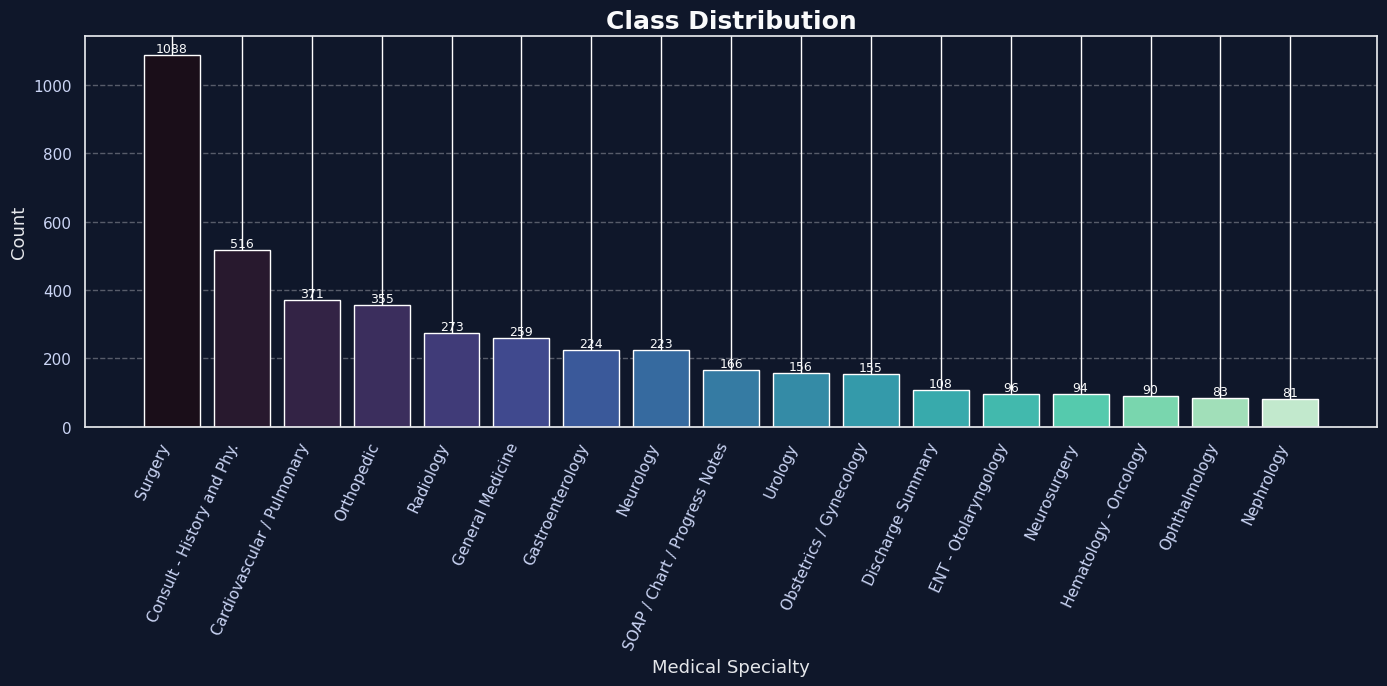

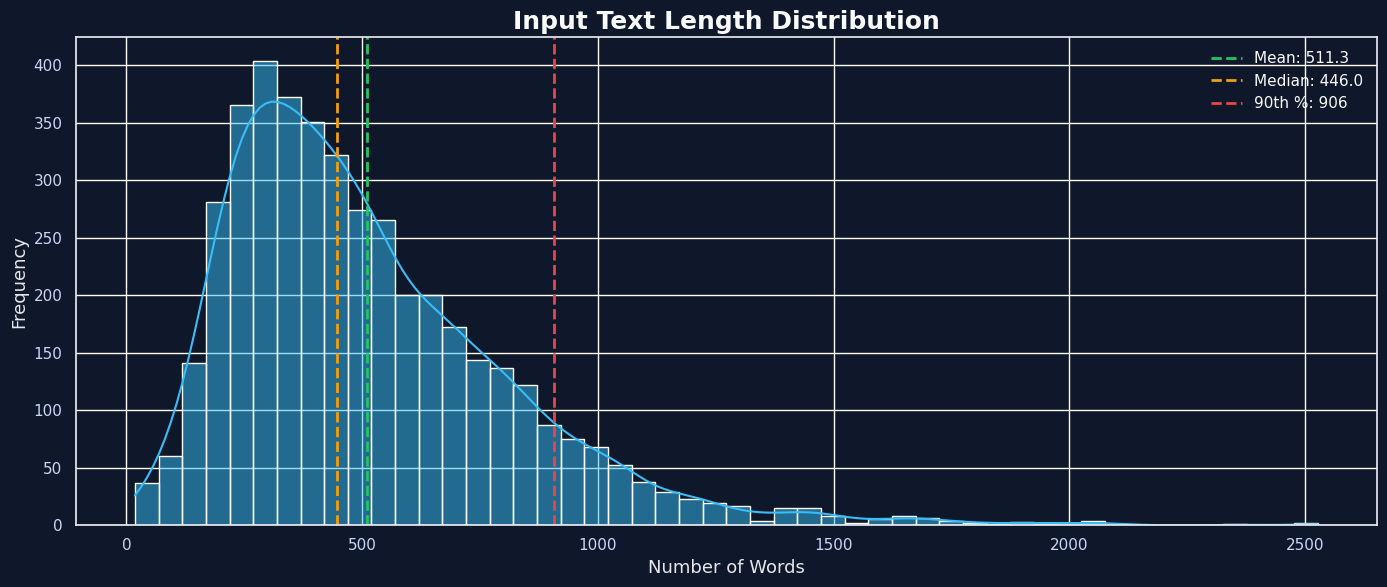

Average words per sample: 511.28
Median words per sample: 446.0
90th percentile words: 906


In [39]:
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#0f172a",
    "axes.facecolor": "#0f172a",
    "axes.edgecolor": "#e5e7eb",
    "axes.labelcolor": "#e5e7eb",
    "text.color": "#f9fafb",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

specialty_counts = df["medical_specialty"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
colors = sns.color_palette("mako", len(specialty_counts))
bars = plt.bar(specialty_counts.index, specialty_counts.values, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

plt.title("Class Distribution", fontsize=18, weight="bold")
plt.xlabel("Medical Specialty", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=65, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

word_lengths = df["input_text"].str.split().str.len()

plt.figure(figsize=(14, 6))
sns.histplot(word_lengths, bins=50, kde=True, color="#38bdf8")

mean_val = word_lengths.mean()
median_val = word_lengths.median()
p90 = word_lengths.quantile(0.90)

plt.axvline(mean_val, color="#22c55e", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color="#f59e0b", linestyle="--", linewidth=2, label=f"Median: {median_val:.1f}")
plt.axvline(p90, color="#ef4444", linestyle="--", linewidth=2, label=f"90th %: {int(p90)}")

plt.title("Input Text Length Distribution", fontsize=18, weight="bold")
plt.xlabel("Number of Words", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"\033[1mAverage words per sample:\033[0m {round(mean_val, 2)}")
print(f"\033[1mMedian words per sample:\033[0m {round(median_val, 2)}")
print(f"\033[1m90th percentile words:\033[0m {int(p90)}")

## Step 6: Label Encoding

Medical specialty labels are converted into numerical form for model training.

Mappings are stored for later inverse decoding during inference.

In [7]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["medical_specialty"])

num_labels = len(le.classes_)
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}

print("Number of classes:", num_labels)
print("Labels:", list(le.classes_))

Number of classes: 17
Labels: ['Cardiovascular / Pulmonary', 'Consult - History and Phy.', 'Discharge Summary', 'ENT - Otolaryngology', 'Gastroenterology', 'General Medicine', 'Hematology - Oncology', 'Nephrology', 'Neurology', 'Neurosurgery', 'Obstetrics / Gynecology', 'Ophthalmology', 'Orthopedic', 'Radiology', 'SOAP / Chart / Progress Notes', 'Surgery', 'Urology']


## Step 7: Stratified Train / Validation / Test Split

The dataset is divided into:
- Training set
- Validation set
- Test set

Stratification preserves class proportions across all splits.

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 3470
Val: 434
Test: 434


## Step 8: Minority-Class Augmentation

This section allows conservative augmentation for minority classes.

It is disabled by default to preserve clinical text integrity.

In [9]:
AUGMENT_MINORITY = False
AUG_THRESHOLD = 150
AUG_FACTOR = 1

if AUGMENT_MINORITY:
    import nltk
    import nlpaug.augmenter.word as naw

    nltk.download("wordnet")
    nltk.download("omw-1.4")
    nltk.download("averaged_perceptron_tagger")
    nltk.download("averaged_perceptron_tagger_eng")

    aug = naw.SynonymAug(aug_src="wordnet", aug_max=2)

    def augment_minority_classes(frame, threshold=150, factor=1):
        class_counts = frame["medical_specialty"].value_counts()
        minority_classes = class_counts[class_counts < threshold].index.tolist()

        augmented_rows = []
        for _, row in frame.iterrows():
            if row["medical_specialty"] in minority_classes:
                for _ in range(factor):
                    try:
                        new_row = row.copy()
                        text_to_aug = row["input_text"][:700]
                        new_text = aug.augment(text_to_aug)
                        if isinstance(new_text, list):
                            new_text = new_text[0]
                        new_row["input_text"] = str(new_text)
                        augmented_rows.append(new_row)
                    except Exception:
                        continue

        if augmented_rows:
            return pd.concat([frame, pd.DataFrame(augmented_rows)], ignore_index=True)
        return frame

    train_df = augment_minority_classes(train_df, threshold=AUG_THRESHOLD, factor=AUG_FACTOR)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print("Augmented train size:", len(train_df))

## Step 9: Compute Class Weights

Balanced class weights are calculated to reduce class imbalance during optimization.

Weights are clipped to avoid unstable gradients.

In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_labels),
    y=train_df["label"],
)
class_weights = np.clip(class_weights, 1.0, 5.0)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([1.0000, 1.0000, 2.3735, 2.6509, 1.1403, 1.0000, 2.8350, 3.1403, 1.1467,
        2.7216, 1.6461, 3.0465, 1.0000, 1.0000, 1.5347, 1.0000, 1.6329])


## Step 10: Load Bio_ClinicalBERT Tokenizer

Bio_ClinicalBERT is selected because it is pretrained on clinical text and performs strongly on medical NLP tasks.

In [11]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
MAX_LEN = 384

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

## Step 11: Long-Document Chunking Strategy

Clinical notes often exceed transformer token limits.

Overlapping chunking is used to:
- preserve long-context information
- reduce truncation loss

In [12]:
CHUNK_STRIDE = 96
CHUNK_MAX_LEN = MAX_LEN


def chunk_text(text, tokenizer, max_len=CHUNK_MAX_LEN, stride=CHUNK_STRIDE):
    """
    Returns a list of text chunks built from overlapping token windows.
    Each chunk is decoded back into a text string so it can be tokenized later.
    """
    enc = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
        truncation=False,
    )
    token_ids = enc["input_ids"]

    if len(token_ids) <= max_len - 2:
        return [text]

    chunks = []
    step = max(1, (max_len - 2) - stride)

    for start in range(0, len(token_ids), step):
        window = token_ids[start : start + (max_len - 2)]
        if not window:
            break
        chunk_text_str = tokenizer.decode(window, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        chunk_text_str = chunk_text_str.strip()
        if chunk_text_str:
            chunks.append(chunk_text_str)
        if start + (max_len - 2) >= len(token_ids):
            break

    return chunks if chunks else [text]


## Step 12: Expand Notes into Chunk-Level Samples

Each long clinical note is split into multiple training chunks.

This significantly improves long-document learning.

In [13]:
def expand_to_chunks(frame):
    rows = []
    for _, row in frame.iterrows():
        chunks = chunk_text(row["input_text"], tokenizer)
        for chunk in chunks:
            rows.append(
                {
                    "input_text": chunk,
                    "label": int(row["label"]),
                    "medical_specialty": row["medical_specialty"],
                }
            )
    return pd.DataFrame(rows)


train_chunks_df = expand_to_chunks(train_df)
val_chunks_df = expand_to_chunks(val_df)
test_chunks_df = expand_to_chunks(test_df)

print("Train chunks:", len(train_chunks_df))
print("Val chunks:", len(val_chunks_df))
print("Test chunks:", len(test_chunks_df))

Train chunks: 11671
Val chunks: 1385
Test chunks: 1471


## Step 13: Tokenization and Dataset Conversion

Chunked text is tokenized and converted into Hugging Face Dataset format for efficient transformer training.

In [14]:
def tokenize_batch(batch):
    return tokenizer(
        batch["input_text"],
        truncation=True,
        max_length=MAX_LEN,
    )


def make_dataset(frame):
    ds = Dataset.from_pandas(frame[["input_text", "label"]].reset_index(drop=True))
    ds = ds.map(tokenize_batch, batched=True, desc="Tokenizing")
    ds = ds.remove_columns(["input_text"])
    ds.set_format(type="torch")
    return ds


train_ds = make_dataset(train_chunks_df)
val_ds = make_dataset(val_chunks_df)
test_ds = make_dataset(test_chunks_df)

Tokenizing:   0%|          | 0/11671 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1385 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1471 [00:00<?, ? examples/s]

## Step 14: Define Evaluation Metrics

Three metrics are tracked:

- Accuracy
- Macro F1-score
- Weighted F1-score

In [15]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

## Step 15: Custom Weighted Loss Trainer

A custom trainer applies weighted cross-entropy loss using computed class weights.

In [16]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = F.cross_entropy(
            logits,
            labels,
            weight=class_weights.to(logits.device),
        )
        return (loss, outputs) if return_outputs else loss

## Step 16: Load Bio_ClinicalBERT Classification Model

The pretrained transformer is initialized for multi-class medical specialty prediction.

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
print(type(model))

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

<class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


## Step 17: Configure Training Strategy

Training includes:
- cosine learning rate schedule
- warmup steps
- gradient accumulation
- mixed precision training

In [18]:
train_batch_size = 4
eval_batch_size = 8
grad_accum = 4
num_train_epochs = 6

steps_per_epoch = math.ceil(len(train_ds) / (train_batch_size * grad_accum))
total_training_steps = steps_per_epoch * num_train_epochs
warmup_steps = max(50, int(0.1 * total_training_steps))

training_args = TrainingArguments(
    output_dir="/content/medical_specialty_out",
    num_train_epochs=num_train_epochs,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=grad_accum,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)


## Step 18: Warm-Up Training Phase

Only the classification head is trained first while freezing encoder layers.

This stabilizes early optimization.

In [19]:
base_model = model.base_model
for param in base_model.parameters():
    param.requires_grad = False

warmup_args = TrainingArguments(
    output_dir="/content/medical_specialty_warmup",
    num_train_epochs=1,
    learning_rate=5e-4,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=grad_accum,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

warmup_trainer = WeightedTrainer(
    model=model,
    args=warmup_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("Starting warm-up training...")
warmup_trainer.train()

for param in base_model.parameters():
    param.requires_grad = True

Starting warm-up training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,9.795809,2.261390,0.412996,0.087933,0.263335


## Step 19: Full Fine-Tuning

All model layers are unfrozen and full transformer fine-tuning is performed.

In [20]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting main training...")
train_result = trainer.train()
print(train_result)

Starting main training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,5.051285,1.169911,0.523466,0.516410,0.519915
2,3.816844,1.157951,0.483032,0.500357,0.474132
3,3.479877,1.199926,0.457762,0.468912,0.452820


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2190, training_loss=4.679521910784996, metrics={'train_runtime': 1047.2775, 'train_samples_per_second': 66.865, 'train_steps_per_second': 4.182, 'total_flos': 6898942388880360.0, 'train_loss': 4.679521910784996, 'epoch': 3.0})


## Step 20: Training Curves Visualization

Loss and validation metrics are plotted across epochs.

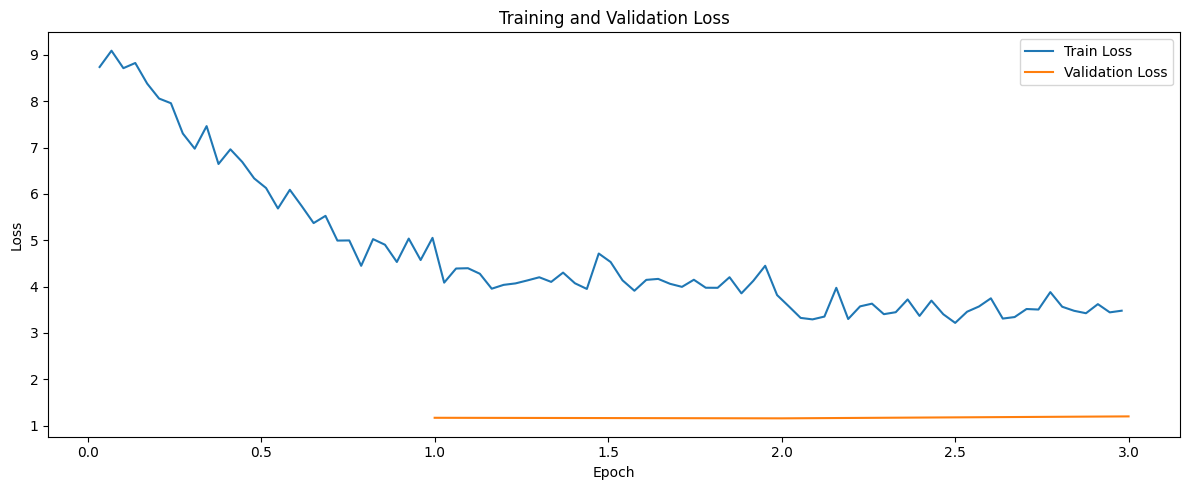

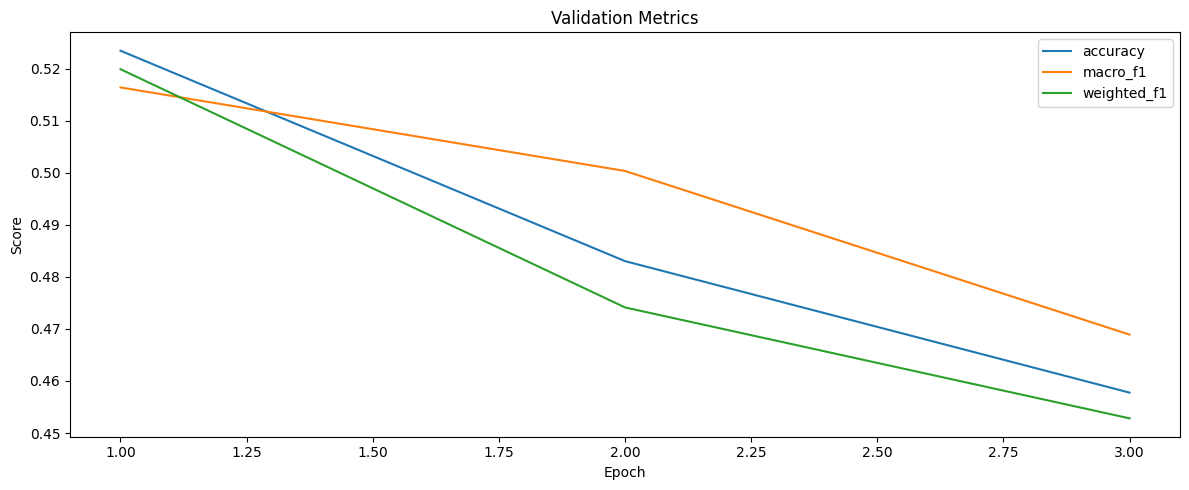

In [21]:
def plot_training_curves(trainer_obj):
    history = pd.DataFrame(trainer_obj.state.log_history)
    if history.empty:
        print("No training history available.")
        return

    plt.figure(figsize=(12, 5))
    if "loss" in history.columns:
        train_loss = history[["epoch", "loss"]].dropna()
        if not train_loss.empty:
            plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss")
    if "eval_loss" in history.columns:
        eval_loss = history[["epoch", "eval_loss"]].dropna()
        if not eval_loss.empty:
            plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    metric_cols = [c for c in ["eval_accuracy", "eval_macro_f1", "eval_weighted_f1"] if c in history.columns]
    if metric_cols:
        plt.figure(figsize=(12, 5))
        for col in metric_cols:
            curve = history[["epoch", col]].dropna()
            if not curve.empty:
                plt.plot(curve["epoch"], curve[col], label=col.replace("eval_", ""))
        plt.title("Validation Metrics")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_training_curves(trainer)

## Step 21: Validation Evaluation (Chunk-Level)

Model performance is first measured on validation chunks.

In [22]:
val_pred = trainer.predict(val_ds)
val_logits = val_pred.predictions
val_labels = val_pred.label_ids
val_preds = np.argmax(val_logits, axis=1)

print("Validation Accuracy:", accuracy_score(val_labels, val_preds))
print("Validation Macro F1:", f1_score(val_labels, val_preds, average="macro"))
print("Validation Weighted F1:", f1_score(val_labels, val_preds, average="weighted"))
print()
print(classification_report(val_labels, val_preds, target_names=le.classes_, zero_division=0))

Validation Accuracy: 0.5249097472924188
Validation Macro F1: 0.5189130771163062
Validation Weighted F1: 0.5214594181396373

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.54      0.39      0.45       124
   Consult - History and Phy.       0.46      0.57      0.51       197
            Discharge Summary       0.47      0.78      0.59        32
         ENT - Otolaryngology       0.51      0.96      0.67        27
             Gastroenterology       0.55      0.84      0.67        56
             General Medicine       0.44      0.35      0.39        95
        Hematology - Oncology       0.62      0.30      0.40        27
                   Nephrology       0.50      0.71      0.59        24
                    Neurology       0.41      0.46      0.44        63
                 Neurosurgery       0.25      0.56      0.34        36
      Obstetrics / Gynecology       0.62      0.81      0.70        42
                Ophthal

## Step 22: Test Evaluation (Chunk-Level)

Chunk-level test performance provides intermediate evaluation.

In [23]:
test_pred = trainer.predict(test_ds)
test_logits = test_pred.predictions
test_labels = test_pred.label_ids
test_preds = np.argmax(test_logits, axis=1)

print("Test Accuracy:", accuracy_score(test_labels, test_preds))
print("Test Macro F1:", f1_score(test_labels, test_preds, average="macro"))
print("Test Weighted F1:", f1_score(test_labels, test_preds, average="weighted"))
print()
print(classification_report(test_labels, test_preds, target_names=le.classes_, zero_division=0))

Test Accuracy: 0.5547246770904147
Test Macro F1: 0.5493577887887258
Test Weighted F1: 0.5540352466278046

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.60      0.47      0.53       118
   Consult - History and Phy.       0.52      0.54      0.53       216
            Discharge Summary       0.48      0.76      0.59        34
         ENT - Otolaryngology       0.72      0.86      0.78        21
             Gastroenterology       0.60      0.65      0.63        72
             General Medicine       0.32      0.38      0.35        77
        Hematology - Oncology       0.38      0.43      0.40        21
                   Nephrology       0.49      0.70      0.58        30
                    Neurology       0.45      0.62      0.53        80
                 Neurosurgery       0.32      0.85      0.47        33
      Obstetrics / Gynecology       0.49      0.81      0.61        58
                Ophthalmology       0.85 

## Step 23: Chunk-Level Confusion Matrix

This visualizes class-wise prediction behavior.

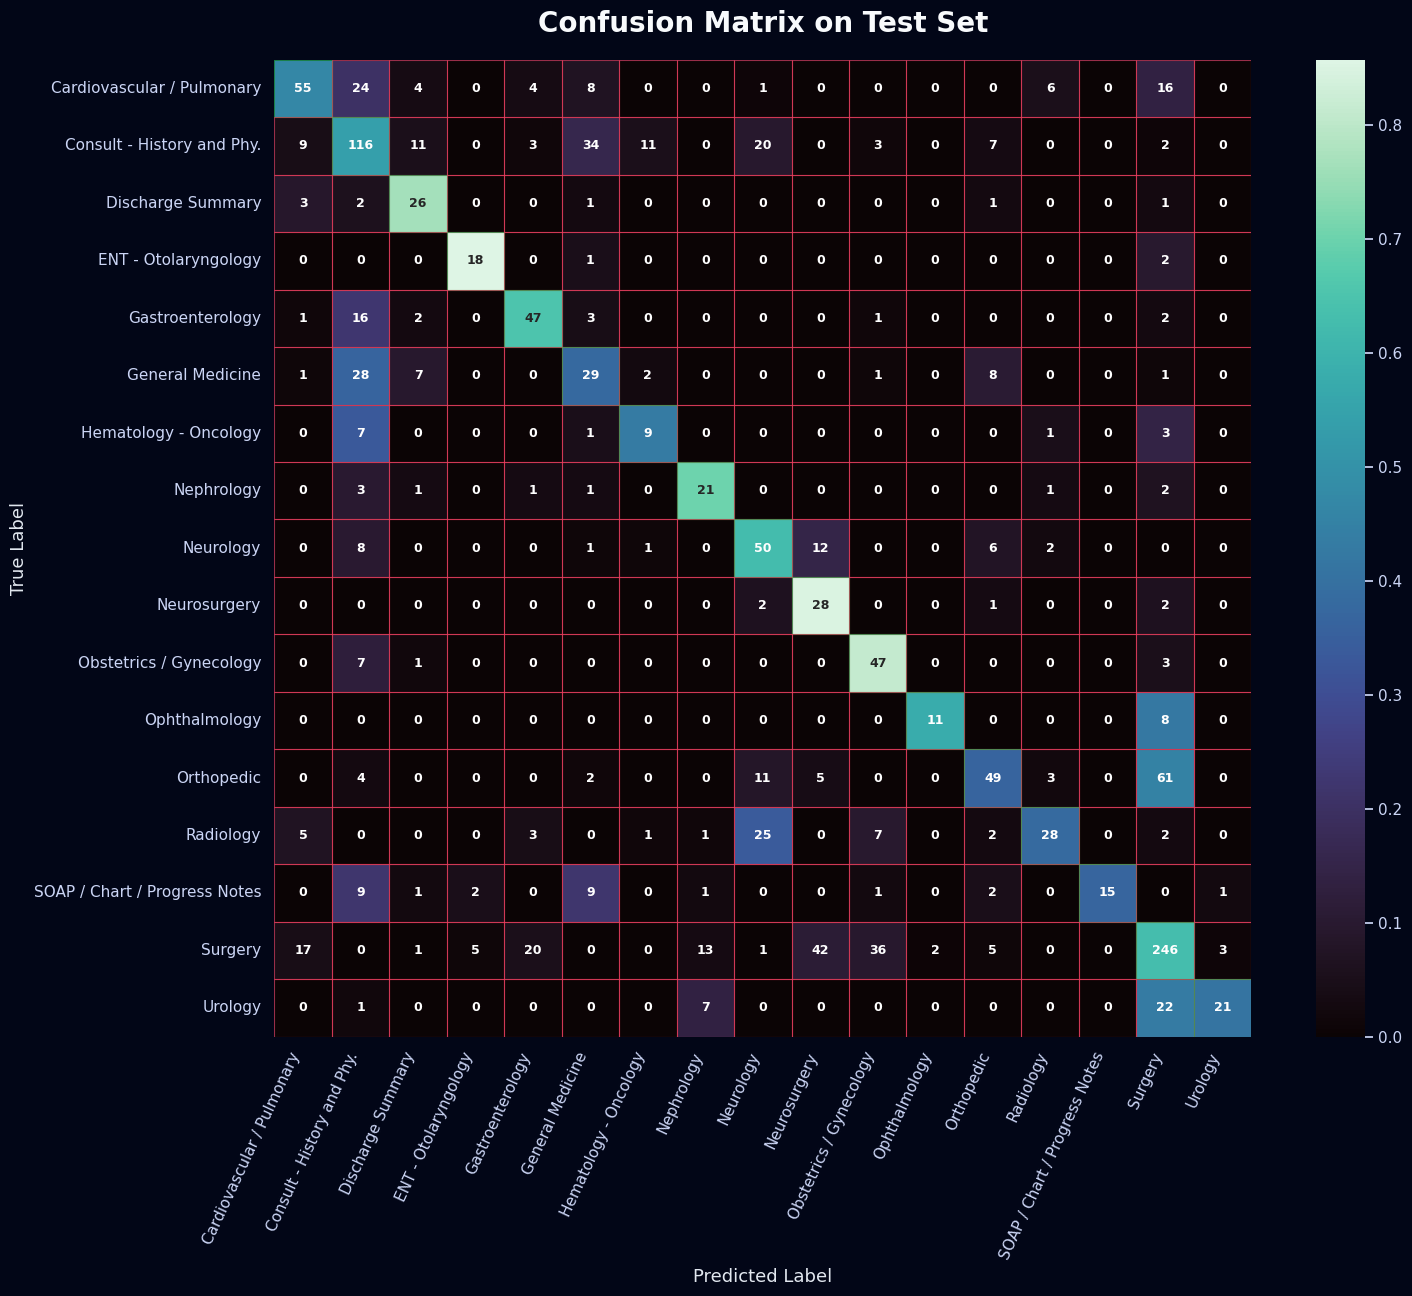

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

sns.set_theme(style="dark")
plt.rcParams.update({
    "figure.facecolor": "#020617",
    "axes.facecolor": "#020617",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#f8fafc",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 13))

heatmap = sns.heatmap(
    cm_norm,
    cmap="mako",
    annot=cm,
    fmt="d",
    linewidths=0.4,
    linecolor="#0f172a",
    cbar=True,
    square=True,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    annot_kws={"size": 9, "weight": "bold"}
)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(colors="#cbd5f5")

plt.title("Confusion Matrix on Test Set", fontsize=20, weight="bold", pad=20)
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.xticks(rotation=65, ha="right")
plt.yticks(rotation=0)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm_norm[i, j]
        color = "#22c55e" if i == j else "#f43f5e"
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=color, linewidth=0.8, alpha=0.6))

plt.tight_layout()
plt.show()

## Step 24: Chunk-Level Per-Class Accuracy

Class-specific accuracy is computed for detailed analysis.

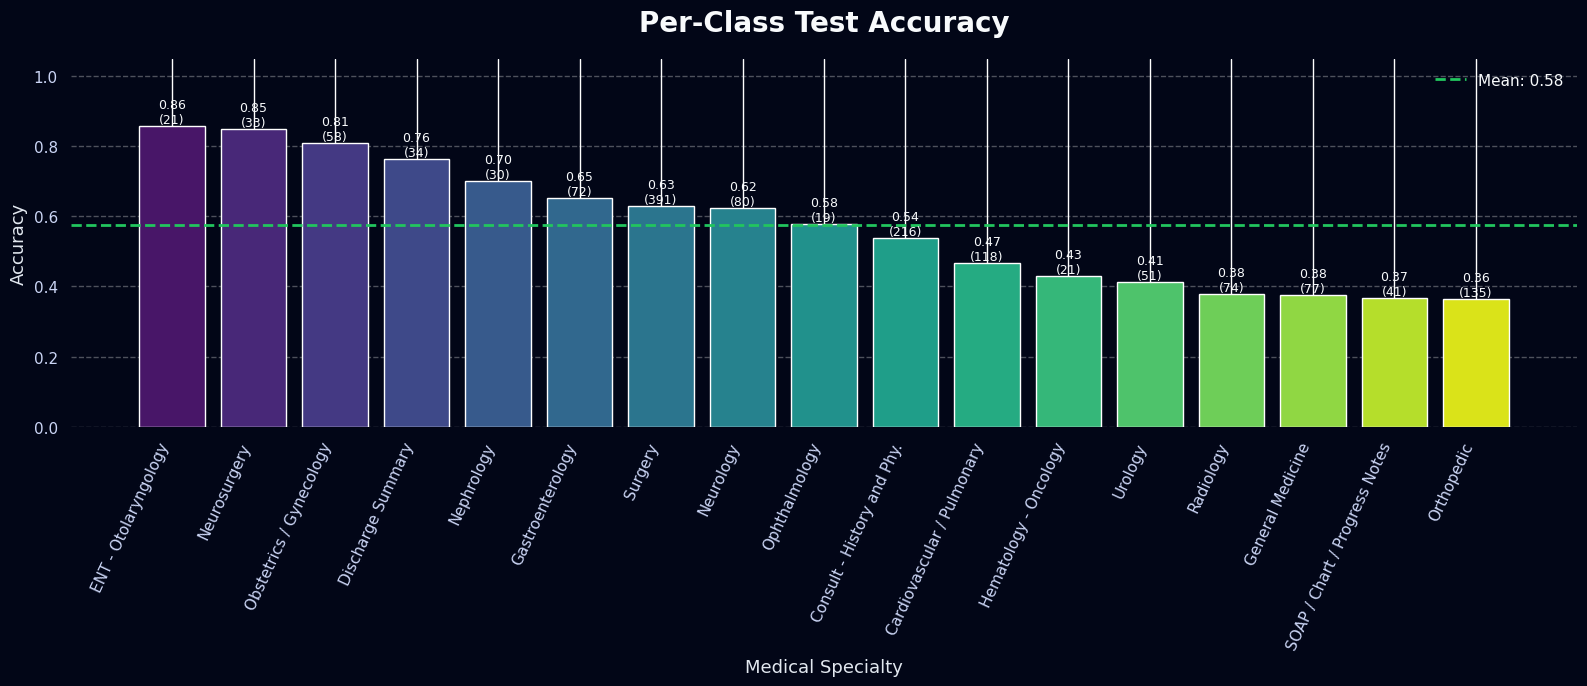

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#020617",
    "axes.facecolor": "#020617",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#f8fafc",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

def per_class_accuracy(y_true, y_pred, label_names):
    results = []
    for idx, name in enumerate(label_names):
        mask = (y_true == idx)
        acc = np.nan if mask.sum() == 0 else (y_pred[mask] == y_true[mask]).mean()
        results.append((name, acc, int(mask.sum())))
    return pd.DataFrame(results, columns=["class", "accuracy", "support"])

pc_df = per_class_accuracy(test_labels, test_preds, le.classes_).sort_values("accuracy", ascending=False)

plt.figure(figsize=(16, 7))
palette = sns.color_palette("viridis", len(pc_df))
bars = plt.bar(pc_df["class"], pc_df["accuracy"], color=palette)

for bar, val, sup in zip(bars, pc_df["accuracy"], pc_df["support"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}\n({sup})",
             ha="center", va="bottom", fontsize=9)

mean_acc = pc_df["accuracy"].mean()
plt.axhline(mean_acc, linestyle="--", linewidth=2, color="#22c55e", label=f"Mean: {mean_acc:.2f}")

plt.title("Per-Class Test Accuracy", fontsize=20, weight="bold", pad=20)
plt.xlabel("Medical Specialty", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.xticks(rotation=65, ha="right")
plt.ylim(0, 1.05)
plt.legend(frameon=False)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

styled_df = pc_df.style.background_gradient(cmap="viridis").format({
    "accuracy": "{:.3f}",
    "support": "{:.0f}"
})

print(styled_df)

## Step 25: Save Final Trained Model

Tokenizer and model weights are saved for future inference and deployment.

In [26]:
save_dir = "/content/final_medical_specialty_model"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Saved model to: {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /content/final_medical_specialty_model


## Step 26: Single Note Inference

A full medical note is predicted using chunk aggregation.

In [27]:
def predict_single_text(text):
    """
    Predict label for one long report by chunking it and averaging logits.
    Returns predicted label, confidence, and full probabilities.
    """
    model.eval()
    chunks = chunk_text(text, tokenizer)
    all_logits = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            all_logits.append(outputs.logits.squeeze(0).detach().cpu().numpy())

    avg_logits = np.mean(np.stack(all_logits, axis=0), axis=0)
    probs = torch.softmax(torch.tensor(avg_logits), dim=-1).numpy()
    pred_id = int(np.argmax(probs))

    return {
        "predicted_label": id2label[pred_id],
        "confidence": float(probs[pred_id]),
        "all_probs": {id2label[i]: float(probs[i]) for i in range(len(probs))},
        "num_chunks": len(chunks),
    }


# Example prediction
sample_text = test_df.iloc[0]["input_text"]
print(predict_single_text(sample_text))

{'predicted_label': 'Discharge Summary', 'confidence': 0.35030657052993774, 'all_probs': {'Cardiovascular / Pulmonary': 0.062127381563186646, 'Consult - History and Phy.': 0.046814702451229095, 'Discharge Summary': 0.35030657052993774, 'ENT - Otolaryngology': 0.03261417895555496, 'Gastroenterology': 0.018928708508610725, 'General Medicine': 0.1090020164847374, 'Hematology - Oncology': 0.038652364164590836, 'Nephrology': 0.06854167580604553, 'Neurology': 0.01973205804824829, 'Neurosurgery': 0.025748025625944138, 'Obstetrics / Gynecology': 0.011128971353173256, 'Ophthalmology': 0.006130266934633255, 'Orthopedic': 0.07495593279600143, 'Radiology': 0.004150985274463892, 'SOAP / Chart / Progress Notes': 0.04400787875056267, 'Surgery': 0.06322719156742096, 'Urology': 0.023931048810482025}, 'num_chunks': 4}


## Step 27: Sample Predictions

Random examples are tested to inspect real inference behavior.

In [28]:
def show_sample_predictions(frame, n=5):
    sample_rows = frame.sample(min(n, len(frame)), random_state=SEED)
    for _, row in sample_rows.iterrows():
        result = predict_single_text(row["input_text"])
        print("=" * 90)
        print("True label:", row["medical_specialty"])
        print("Pred label:", result["predicted_label"])
        print("Confidence:", round(result["confidence"], 4))
        print("Chunks used:", result["num_chunks"])
        print("Text preview:", row["input_text"][:350])
        print()

show_sample_predictions(test_df, n=3)

True label: Surgery
Pred label: Surgery
Confidence: 0.6368
Chunks used: 5
Text preview: Sample name: Hysteroscopy & Laproscopy with Salpingooophorectomy [SEP] Description: Dilation and curettage (D&C), hysteroscopy, and laparoscopy with right salpingooophorectomy and aspiration of cyst fluid.  Thickened endometrium and tamoxifen therapy, adnexal cyst, endometrial polyp, and right ovarian cyst. [SEP] Keywords: surgery, adnexal cyst, en

True label: Cardiovascular / Pulmonary
Pred label: Cardiovascular / Pulmonary
Confidence: 0.7826
Chunks used: 2
Text preview: Sample name: Hickman Central Venous Catheter Placement [SEP] Description: Placement of a subclavian single-lumen tunneled Hickman central venous catheter.  Surgeon-interpreted fluoroscopy. [SEP] Keywords: cardiovascular / pulmonary, j wire, distal tip, stab incision, tunneled, hickman central venous catheter, subclavian, venous, fluoroscopy, hickma

True label: Surgery
Pred label: Surgery
Confidence: 0.8721
Chunks used: 2
Text pre

## Step 28: Note-Level Aggregation Logic

Chunk logits are averaged to produce final note-level prediction.

In [29]:
def predict_note(text):
    """
    Predict a single label for one full medical note.
    The note is chunked, each chunk is predicted, and logits are averaged.
    """
    model.eval()
    chunks = chunk_text(text, tokenizer)
    logits_list = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits_list.append(outputs.logits.squeeze(0).cpu().numpy())

    avg_logits = np.mean(np.stack(logits_list, axis=0), axis=0)
    probs = torch.softmax(torch.tensor(avg_logits), dim=-1).numpy()
    pred_id = int(np.argmax(probs))

    return pred_id, probs

## Step 29: Validation Evaluation (Note-Level)

This reflects real-world deployment behavior.

In [30]:
def evaluate_note_level(frame, split_name="Validation"):
    y_true = []
    y_pred = []
    all_probs = []

    for _, row in frame.iterrows():
        pred_id, probs = predict_note(row["input_text"])
        y_true.append(int(row["label"]))
        y_pred.append(pred_id)
        all_probs.append(probs)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"{split_name} Accuracy:", accuracy_score(y_true, y_pred))
    print(f"{split_name} Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print(f"{split_name} Weighted F1:", f1_score(y_true, y_pred, average="weighted"))
    print()
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

    return y_true, y_pred, np.array(all_probs)


val_true, val_pred, val_probs = evaluate_note_level(val_df, "Validation")

Validation Accuracy: 0.804147465437788
Validation Macro F1: 0.7798855261069422
Validation Weighted F1: 0.8051081817670405

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.88      0.76      0.81        37
   Consult - History and Phy.       0.52      0.73      0.61        52
            Discharge Summary       0.69      1.00      0.81        11
         ENT - Otolaryngology       0.83      1.00      0.91        10
             Gastroenterology       1.00      0.86      0.93        22
             General Medicine       0.86      0.46      0.60        26
        Hematology - Oncology       1.00      0.33      0.50         9
                   Nephrology       0.78      0.88      0.82         8
                    Neurology       0.57      0.55      0.56        22
                 Neurosurgery       0.62      0.89      0.73         9
      Obstetrics / Gynecology       0.93      0.88      0.90        16
                Ophthalm

## Step 30: Final Test Evaluation (Note-Level)

This is the primary final performance metric of the project.

In [31]:
test_true, test_pred, test_probs = evaluate_note_level(test_df, "Test")

Test Accuracy: 0.8179723502304147
Test Macro F1: 0.8137288506341217
Test Weighted F1: 0.8221656648932348

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.87      0.70      0.78        37
   Consult - History and Phy.       0.57      0.80      0.67        51
            Discharge Summary       0.73      1.00      0.85        11
         ENT - Otolaryngology       0.90      1.00      0.95         9
             Gastroenterology       0.94      0.70      0.80        23
             General Medicine       0.70      0.62      0.65        26
        Hematology - Oncology       0.86      0.67      0.75         9
                   Nephrology       0.70      0.88      0.78         8
                    Neurology       0.79      0.65      0.71        23
                 Neurosurgery       0.53      1.00      0.69        10
      Obstetrics / Gynecology       0.76      0.87      0.81        15
                Ophthalmology       1.00 

## Step 31: Note-Level Confusion Matrix

Shows note-level class interactions after aggregation.

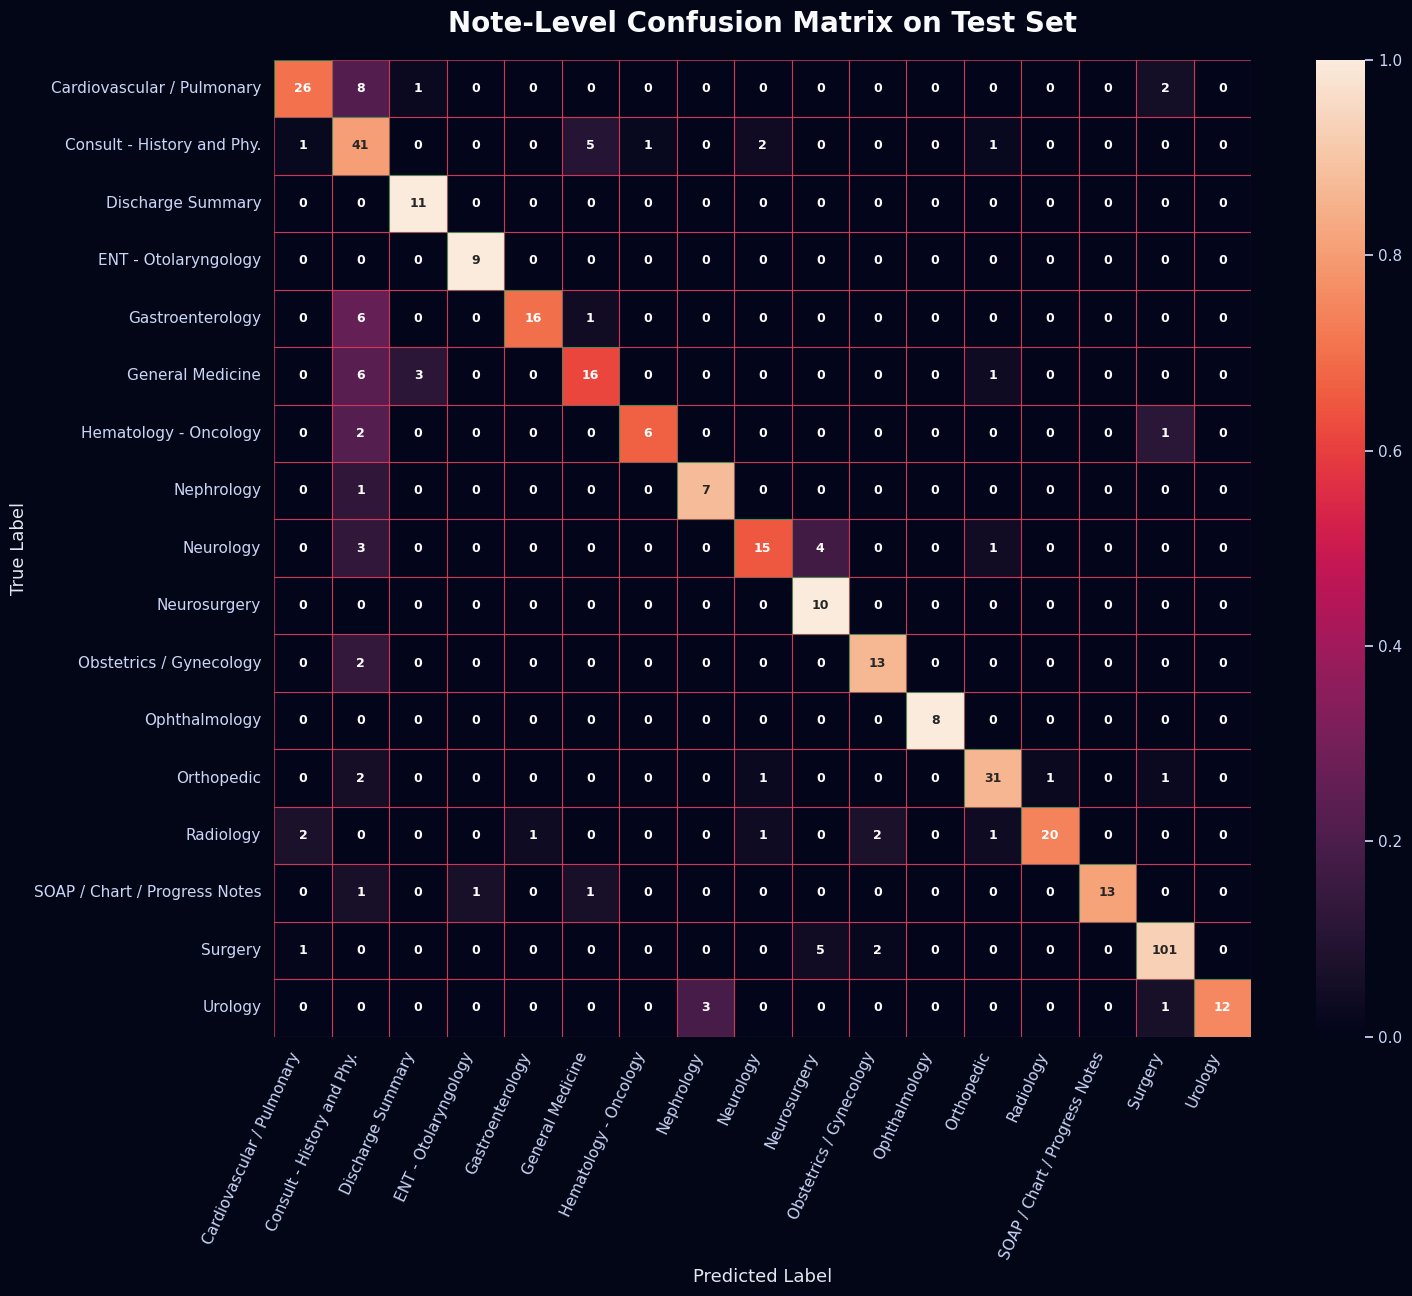

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

sns.set_theme(style="dark")
plt.rcParams.update({
    "figure.facecolor": "#020617",
    "axes.facecolor": "#020617",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#f8fafc",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

cm_note = confusion_matrix(test_true, test_pred)
cm_norm = cm_note.astype("float") / cm_note.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 13))

heatmap = sns.heatmap(
    cm_norm,
    cmap="rocket",
    annot=cm_note,
    fmt="d",
    linewidths=0.4,
    linecolor="#0f172a",
    cbar=True,
    square=True,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    annot_kws={"size": 9, "weight": "bold"}
)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(colors="#cbd5f5")

plt.title("Note-Level Confusion Matrix on Test Set", fontsize=20, weight="bold", pad=20)
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.xticks(rotation=65, ha="right")
plt.yticks(rotation=0)

for i in range(cm_note.shape[0]):
    for j in range(cm_note.shape[1]):
        value = cm_norm[i, j]
        color = "#22c55e" if i == j else "#f43f5e"
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=color, linewidth=0.8, alpha=0.6))

plt.tight_layout()
plt.show()

## Step 32: Note-Level Per-Class Accuracy

Final class-wise note prediction performance.

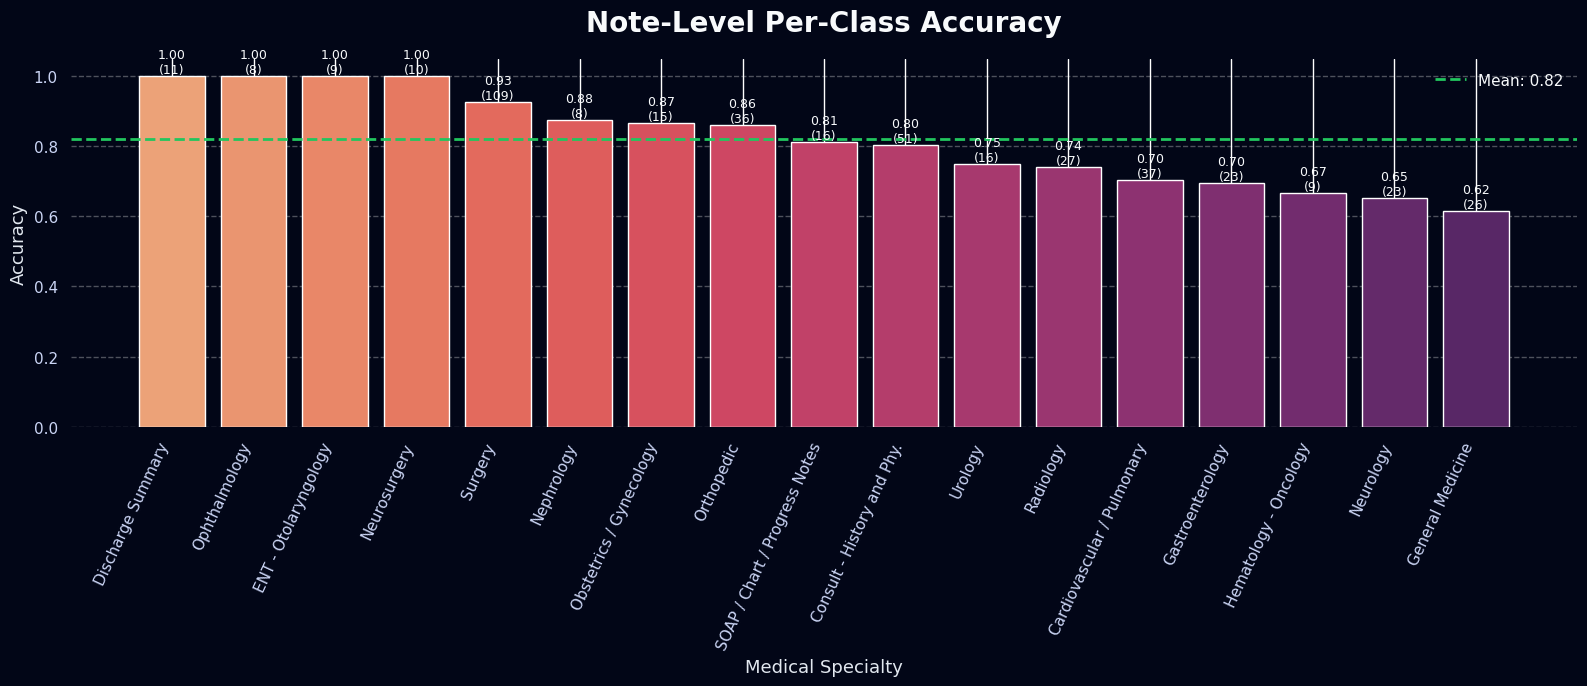

,class,accuracy,support
2,Discharge Summary,1.000,11
11,Ophthalmology,1.000,8
3,ENT - Otolaryngology,1.000,9
9,Neurosurgery,1.000,10
15,Surgery,0.927,109
7,Nephrology,0.875,8
10,Obstetrics / Gynecology,0.867,15
12,Orthopedic,0.861,36
14,SOAP / Chart / Progress Notes,0.812,16
1,Consult - History and Phy.,0.804,51


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import display

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#020617",
    "axes.facecolor": "#020617",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#f8fafc",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

note_pc_df = per_class_accuracy(test_true, test_pred, le.classes_).sort_values(
    "accuracy", ascending=False
)

plt.figure(figsize=(16, 7))
palette = sns.color_palette("flare", len(note_pc_df))
bars = plt.bar(note_pc_df["class"], note_pc_df["accuracy"], color=palette)

for bar, val, sup in zip(bars, note_pc_df["accuracy"], note_pc_df["support"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}\n({sup})",
        ha="center",
        va="bottom",
        fontsize=9
    )

mean_acc = note_pc_df["accuracy"].mean()
plt.axhline(mean_acc, linestyle="--", linewidth=2, color="#22c55e", label=f"Mean: {mean_acc:.2f}")

plt.title("Note-Level Per-Class Accuracy", fontsize=20, weight="bold", pad=20)
plt.xlabel("Medical Specialty", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.xticks(rotation=65, ha="right")
plt.ylim(0, 1.05)
plt.legend(frameon=False)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

styled_df = note_pc_df.style.background_gradient(cmap="flare").format({
    "accuracy": "{:.3f}",
    "support": "{:.0f}"
})

display(styled_df)

## Step 33: Save Note-Level Predictions

Predictions are exported for external review and reporting.

In [34]:
test_note_results = test_df.copy().reset_index(drop=True)
test_note_results["true_label"] = test_true
test_note_results["pred_label"] = test_pred
test_note_results["true_label_name"] = test_note_results["true_label"].map(id2label)
test_note_results["pred_label_name"] = test_note_results["pred_label"].map(id2label)

display(test_note_results[[
    "medical_specialty",
    "true_label_name",
    "pred_label_name"
]].head())

test_note_results.to_csv("/content/note_level_test_predictions.csv", index=False)
print("Saved: /content/note_level_test_predictions.csv")

,medical_specialty,true_label_name,pred_label_name
0,General Medicine,General Medicine,Discharge Summary
1,Gastroenterology,Gastroenterology,General Medicine
2,General Medicine,General Medicine,General Medicine
3,Surgery,Surgery,Surgery
4,Cardiovascular / Pulmonary,Cardiovascular / Pulmonary,Cardiovascular / Pulmonary


Saved: /content/note_level_test_predictions.csv


## Step 34: Error Analysis

Incorrect predictions are isolated for deeper model inspection.

In [35]:
errors = test_note_results[
    test_note_results["true_label_name"] != test_note_results["pred_label_name"]
]

display(errors[[
    "medical_specialty",
    "true_label_name",
    "pred_label_name",
    "input_text"
]].head(10))

,medical_specialty,true_label_name,pred_label_name,input_text
0,General Medicine,General Medicine,Discharge Summary,Sample name: Chronic Abscesses - Discharge Sum...
1,Gastroenterology,Gastroenterology,General Medicine,Sample name: Discharge Summary - Cholelithiasi...
10,Cardiovascular / Pulmonary,Cardiovascular / Pulmonary,Consult - History and Phy.,Sample name: COPD & Pneumonia - SOAP [SEP] Des...
20,Neurology,Neurology,Consult - History and Phy.,Sample name: SOAP - Numbness & Tingling [SEP] ...
21,Cardiovascular / Pulmonary,Cardiovascular / Pulmonary,Consult - History and Phy.,Sample name: Chest discomfort & palpitations -...
27,Neurology,Neurology,Neurosurgery,Sample name: Craniotomy - Occipital [SEP] Desc...
37,Orthopedic,Orthopedic,Consult - History and Phy.,Sample name: Orthopedic Consult [SEP] Descript...
43,Orthopedic,Orthopedic,Consult - History and Phy.,Sample name: Pediatric Rheumatology Consult [S...
44,Cardiovascular / Pulmonary,Cardiovascular / Pulmonary,Surgery,"Sample name: Esophagogastrectomy, Jejunostomy,..."
45,Consult - History and Phy.,Consult - History and Phy.,Neurology,Sample name: Granulomatous Inflammation [SEP] ...


## Step 35: Confidence Distribution Analysis

Prediction confidence helps assess model certainty and calibration.

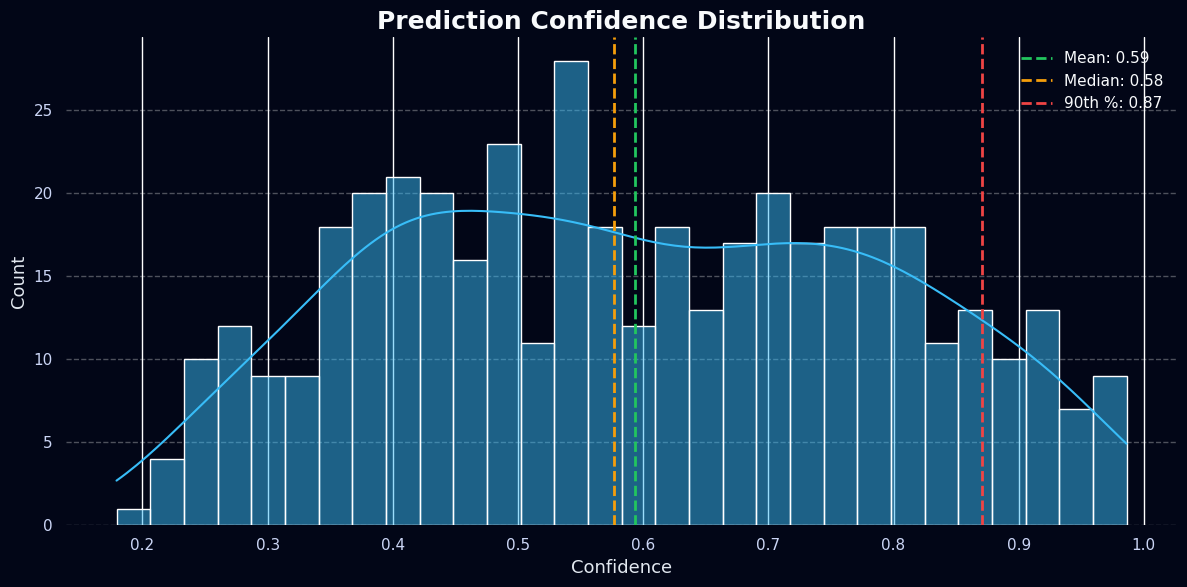

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#020617",
    "axes.facecolor": "#020617",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#f8fafc",
    "xtick.color": "#cbd5f5",
    "ytick.color": "#cbd5f5",
    "font.size": 11
})

confidences = []

for _, row in test_df.iterrows():
    _, probs = predict_note(row["input_text"])
    confidences.append(float(np.max(probs)))

confidences = np.array(confidences)

plt.figure(figsize=(12, 6))
sns.histplot(confidences, bins=30, kde=True, color="#38bdf8")

mean_val = confidences.mean()
median_val = np.median(confidences)
p90 = np.quantile(confidences, 0.90)

plt.axvline(mean_val, linestyle="--", linewidth=2, color="#22c55e", label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle="--", linewidth=2, color="#f59e0b", label=f"Median: {median_val:.2f}")
plt.axvline(p90, linestyle="--", linewidth=2, color="#ef4444", label=f"90th %: {p90:.2f}")

plt.title("Prediction Confidence Distribution", fontsize=18, weight="bold")
plt.xlabel("Confidence", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.legend(frameon=False)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()